In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("data.csv", encoding="latin1")
print(df)

       InvoiceNo StockCode  ... CustomerID         Country
0         536365    85123A  ...    17850.0  United Kingdom
1         536365     71053  ...    17850.0  United Kingdom
2         536365    84406B  ...    17850.0  United Kingdom
3         536365    84029G  ...    17850.0  United Kingdom
4         536365    84029E  ...    17850.0  United Kingdom
...          ...       ...  ...        ...             ...
541904    581587     22613  ...    12680.0          France
541905    581587     22899  ...    12680.0          France
541906    581587     23254  ...    12680.0          France
541907    581587     23255  ...    12680.0          France
541908    581587     22138  ...    12680.0          France

[541909 rows x 8 columns]


In [5]:
print("Data load successful: \n")

Data load successful: 



In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [8]:
print("shape (rows,cols:)", df.shape)

shape (rows,cols:) (541909, 8)


In [9]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

## Step 2- Basic Exploration

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [11]:
print("Col- missing nulls: \n", df.isnull().sum())

Col- missing nulls: 
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [12]:
df.duplicated().count()

np.int64(541909)

In [13]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Step 3 - Data Cleaning

In [14]:
df=df.dropna(subset=["Description"])

In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [16]:
df_cust=df.dropna(subset=["CustomerID"]).copy()
df_cust["CustomerID"]=df_cust["CustomerID"].astype(int)
print(df_cust)


       InvoiceNo StockCode  ... CustomerID         Country
0         536365    85123A  ...      17850  United Kingdom
1         536365     71053  ...      17850  United Kingdom
2         536365    84406B  ...      17850  United Kingdom
3         536365    84029G  ...      17850  United Kingdom
4         536365    84029E  ...      17850  United Kingdom
...          ...       ...  ...        ...             ...
541904    581587     22613  ...      12680          France
541905    581587     22899  ...      12680          France
541906    581587     23254  ...      12680          France
541907    581587     23255  ...      12680          France
541908    581587     22138  ...      12680          France

[406829 rows x 8 columns]


In [17]:
df["IsCancelled"]=df["InvoiceNo"].astype(str).str.startswith("c").sum()

In [18]:
df["IsCancelled"]

0         0
1         0
2         0
3         0
4         0
         ..
541904    0
541905    0
541906    0
541907    0
541908    0
Name: IsCancelled, Length: 540455, dtype: int64

In [19]:
df_clean=df[(~df["IsCancelled"]) & #rows where IsCancelled is False
            (df["Quantity"]>0) & #keep and check quantity is greater than 0
            (df["UnitPrice"]>0) #keep only and check rows UnitPrice is greater than 0
            ].copy() #seperate copy of filtered df

In [20]:
df_clean["InvoiceDate"]=pd.to_datetime(df_clean["InvoiceDate"],format="%m/%d/%Y %H:%M")

In [21]:
df_clean["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 530104, dtype: datetime64[us]

In [22]:
df_clean["TotalPrice"]=np.multiply(df_clean["Quantity"], df_clean["UnitPrice"])

In [23]:
print("STEP 3: Data Cleaned")
print("Original rows: ", df.shape[0], "| Clean rows:", df_clean.shape[0])
print("Cancelled orders removed: ", df["IsCancelled"].sum())
print(df_clean[["InvoiceNo", "Quantity", "UnitPrice", "TotalPrice", "InvoiceDate"]].head())
print("\n")

STEP 3: Data Cleaned
Original rows:  540455 | Clean rows: 530104
Cancelled orders removed:  0
  InvoiceNo  Quantity  UnitPrice  TotalPrice         InvoiceDate
0    536365         6       2.55       15.30 2010-12-01 08:26:00
1    536365         6       3.39       20.34 2010-12-01 08:26:00
2    536365         8       2.75       22.00 2010-12-01 08:26:00
3    536365         6       3.39       20.34 2010-12-01 08:26:00
4    536365         6       3.39       20.34 2010-12-01 08:26:00




## Step 4 - Date Based Features (for time analysis)

In [24]:
df_clean["Year"]=df_clean["InvoiceDate"].dt.year
df_clean["Month"]=df_clean["InvoiceDate"].dt.month
df_clean["Day"]=df_clean["InvoiceDate"].dt.day
df_clean["Hour"]=df_clean["InvoiceDate"].dt.hour
df_clean["DayOfWeek"]=df_clean["InvoiceDate"].dt.day_name()

In [25]:
print("Step 4- Date features added")
print(df_clean[["InvoiceDate","Year","Month","DayOfWeek","Hour"]].head(10))
print("\n")

Step 4- Date features added
          InvoiceDate  Year  Month  DayOfWeek  Hour
0 2010-12-01 08:26:00  2010     12  Wednesday     8
1 2010-12-01 08:26:00  2010     12  Wednesday     8
2 2010-12-01 08:26:00  2010     12  Wednesday     8
3 2010-12-01 08:26:00  2010     12  Wednesday     8
4 2010-12-01 08:26:00  2010     12  Wednesday     8
5 2010-12-01 08:26:00  2010     12  Wednesday     8
6 2010-12-01 08:26:00  2010     12  Wednesday     8
7 2010-12-01 08:28:00  2010     12  Wednesday     8
8 2010-12-01 08:28:00  2010     12  Wednesday     8
9 2010-12-01 08:34:00  2010     12  Wednesday     8




## Step 5- Key Business Metrices

In [26]:
total_rev=np.sum(df_clean["TotalPrice"])
total_orders=df_clean["InvoiceNo"].nunique()
total_cust=df_clean["CustomerID"].nunique()
avg_order_value=df_clean.groupby("InvoiceNo")["TotalPrice"].sum().mean()

In [27]:
print("Step 5- Key Metrices")
print(f"Total Revenue: {total_rev:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_cust}")
print(f"Total Order Value: {avg_order_value:,.2f}")

Step 5- Key Metrices
Total Revenue: 10,666,684.54
Total Orders: 19960
Total Customers: 4338
Total Order Value: 534.40


## Step 6- Top 10 Prodcuts

In [28]:
top_prdcts_rev=(
    df_clean.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_prdcts_qty=(
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [29]:
print(top_prdcts_qty)
print(top_prdcts_rev)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64
Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: TotalPrice, dtype: fl

## Step 7- Country Wise Analysis

In [30]:
country_rev=(
    df_clean.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

In [31]:
print(country_rev.astype(int))

Country
United Kingdom          9025222
Netherlands              285446
EIRE                     283453
Germany                  228867
France                   209715
Australia                138521
Spain                     61577
Switzerland               57089
Belgium                   41196
Sweden                    38378
Japan                     37416
Norway                    36165
Portugal                  33747
Finland                   22546
Singapore                 21279
Channel Islands           20450
Denmark                   18955
Italy                     17483
Hong Kong                 15691
Cyprus                    13590
Austria                   10198
Israel                     8135
Poland                     7334
Greece                     4760
Unspecified                4749
Iceland                    4310
Canada                     3666
USA                        3580
Malta                      2725
United Arab Emirates       1902
Lebanon                    1693


## Step 8- Monthly Sales trend

In [32]:
df_clean["YearMonth"]=df_clean["InvoiceDate"].dt.to_period("M")
monthly_sales=df_clean.groupby("YearMonth")["TotalPrice"].sum()

In [33]:
print(monthly_sales)

YearMonth
2010-12     823746.140
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638792.680
Freq: M, Name: TotalPrice, dtype: float64


## Step 9- Top 10 Customers (Customer Analysis- RFM style)

In [34]:
cust_summary= df_clean.groupby("CustomerID").agg(
    TotalSpent=("TotalPrice","sum"),
    NumOrders=("InvoiceNo","nunique"),
    AvgOrderValue=("TotalPrice","mean"),
    LastPurchase=("InvoiceDate","max")
).sort_values("TotalSpent",ascending=False)

In [35]:
print(cust_summary.head(5))

            TotalSpent  NumOrders  AvgOrderValue        LastPurchase
CustomerID                                                          
14646.0      280206.02         73     134.973998 2011-12-08 12:12:00
18102.0      259657.30         60     602.453132 2011-12-09 11:50:00
17450.0      194550.79         46     577.302047 2011-12-01 13:29:00
16446.0      168472.50          2   56157.500000 2011-12-09 09:15:00
14911.0      143825.06        201      25.343623 2011-12-08 15:54:00


## Step 10- Numpy based staticstical analysis

In [36]:
order_value= df_clean.groupby("InvoiceNo")["TotalPrice"].sum()

In [37]:
order_value

InvoiceNo
536365       139.12
536366        22.20
536367       278.73
536368        70.05
536369        17.85
             ...   
581584       140.64
581585       329.05
581586       339.20
581587       249.45
A563185    11062.06
Name: TotalPrice, Length: 19960, dtype: float64

In [38]:
print("Mean:", np.mean(order_value))
print("Median:", np.median(order_value))
print("Standard Deviation:", np.std(order_value))
print("Max:", np.max(order_value))
print("Min:", np.min(order_value))
print("25th Percentile:", np.percentile(order_value,25))
print("75th Percentile:", np.percentile(order_value,75))
print()

Mean: 534.403033266533
Median: 303.83500000000004
Standard Deviation: 1780.4430456461234
Max: 168469.6
Min: 0.38
25th Percentile: 152.51
75th Percentile: 495.615



## Step 11- Save Cleaned data and summary outputs

In [39]:
df_clean.to_csv("cleaned_ecommerce_data.csv", index=False)
cust_summary.to_csv("cust_summary.csv")
country_rev.to_csv("country_rev.csv")

# Visualisation

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

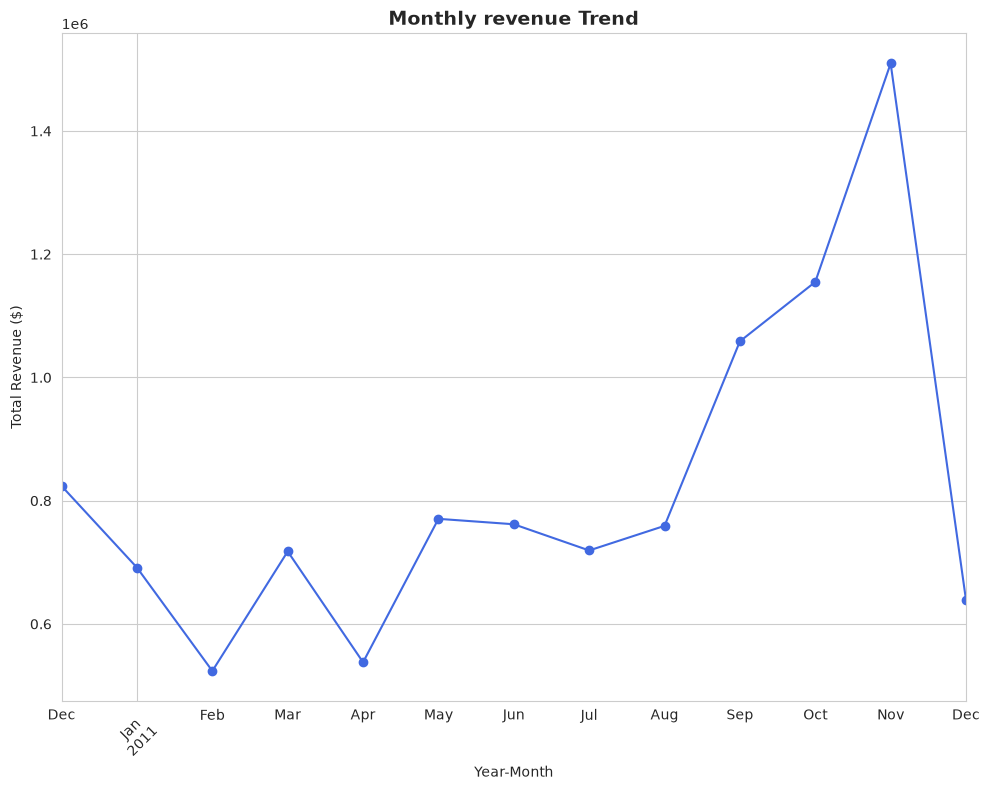

In [41]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,8)

plt.figure()
monthly_sales.plot(kind="line", marker="o", color="royalblue")
plt.title("Monthly revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_26903/257423218.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


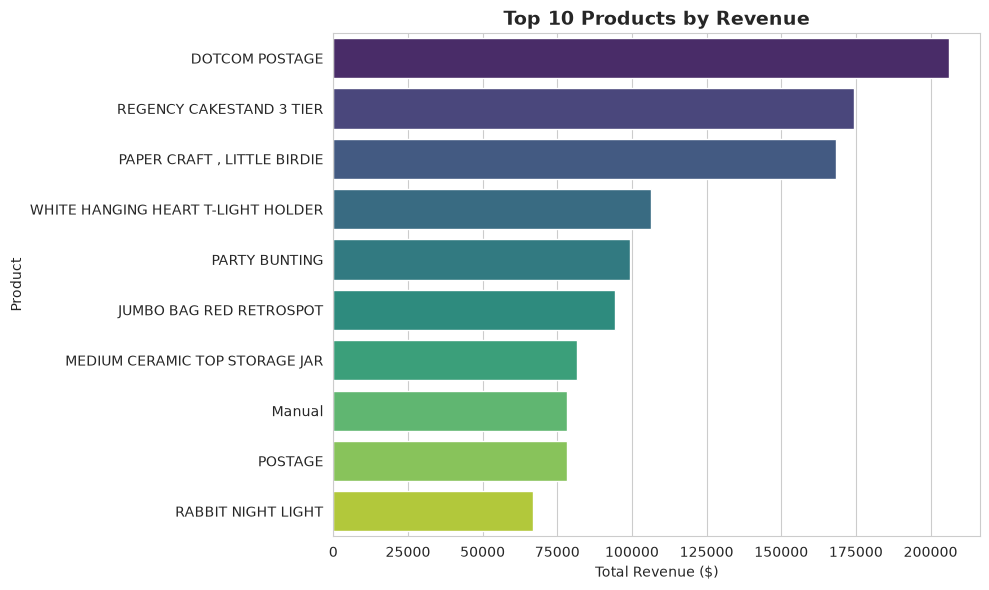

In [42]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_prdcts_rev.values,
    y=top_prdcts_rev.index,
    palette="viridis"
)
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("top_prdcts_rev.png", dpi=150)
plt.show()

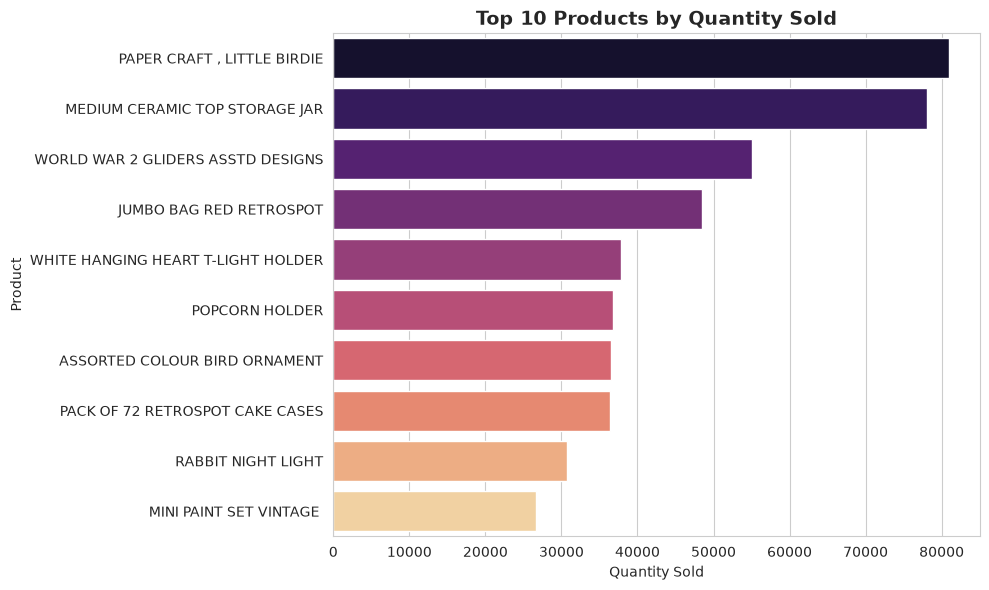

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_prdcts_qty.values,
    y=top_prdcts_qty.index,
    hue=top_prdcts_qty.index,
    palette="magma"
)
plt.title("Top 10 Products by Quantity Sold", fontsize=14, fontweight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("top_prdcts_qty.png", dpi=150)
plt.show()

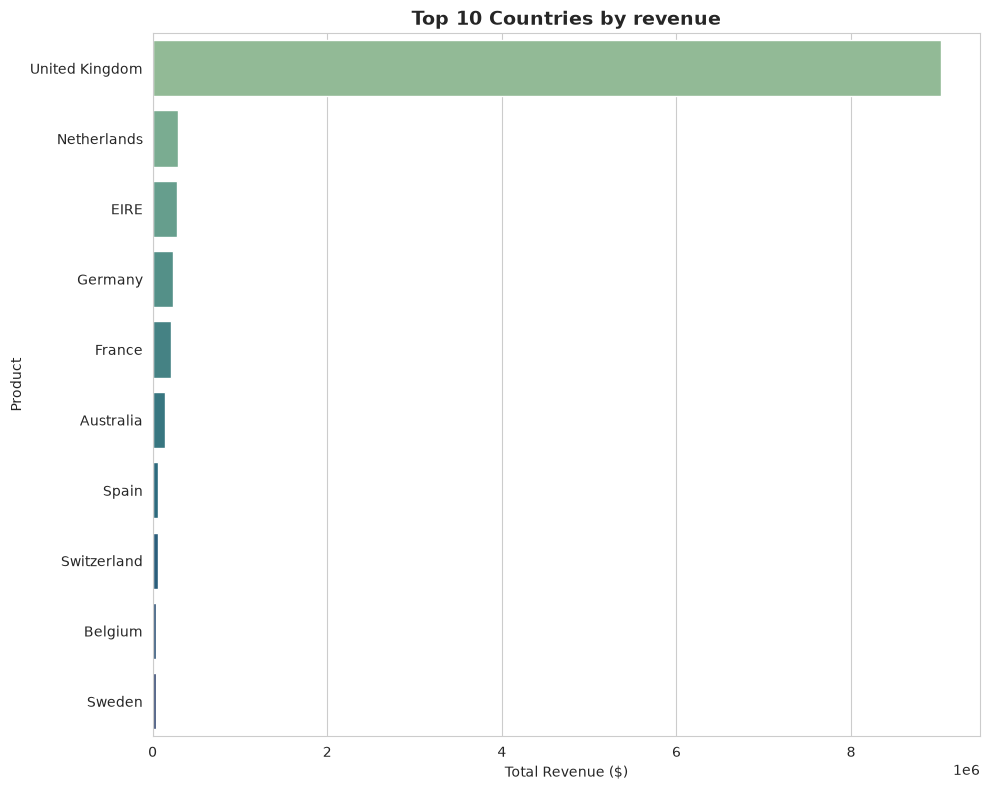

In [44]:
plt.figure()
top_countries=country_rev.head(10)
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="crest"
)
plt.title("Top 10 Countries by revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig("top_countries.png", dpi=150)
plt.show()

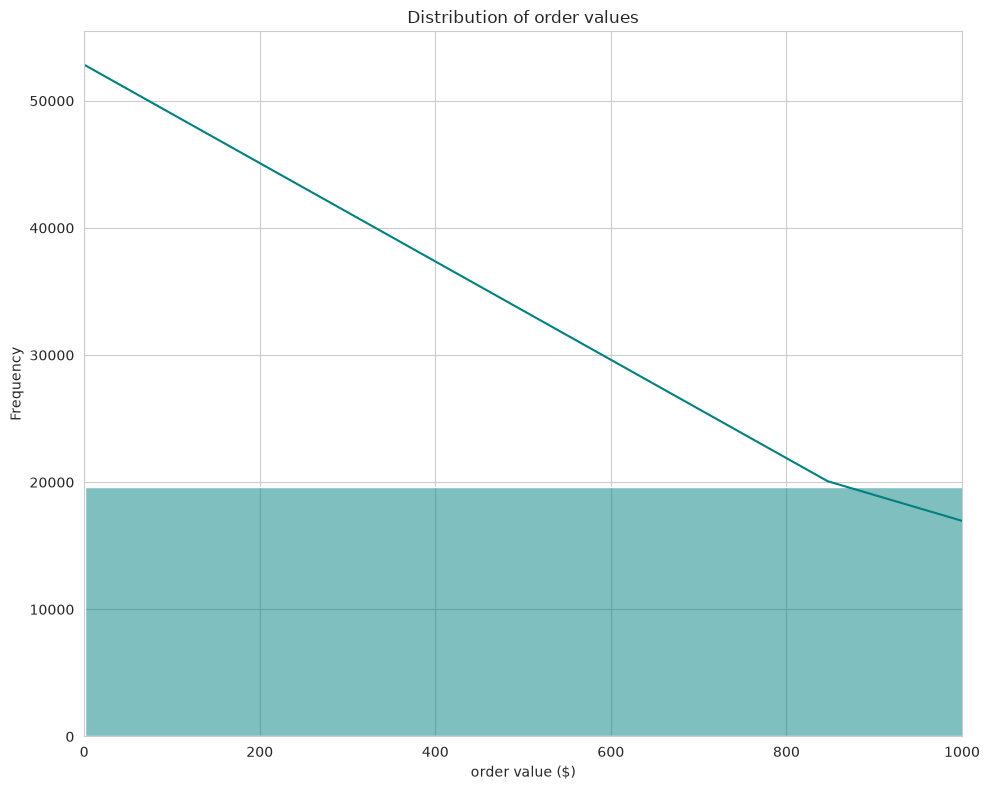

In [45]:
plt.figure()
sns.histplot(order_value, bins=50, kde=True, color="teal")
plt.title("Distribution of order values")
plt.xlabel("order value ($)")
plt.ylabel("Frequency")
plt.xlim(0,1000)
plt.tight_layout()
plt.savefig("order_value.png", dpi=150)
plt.show()

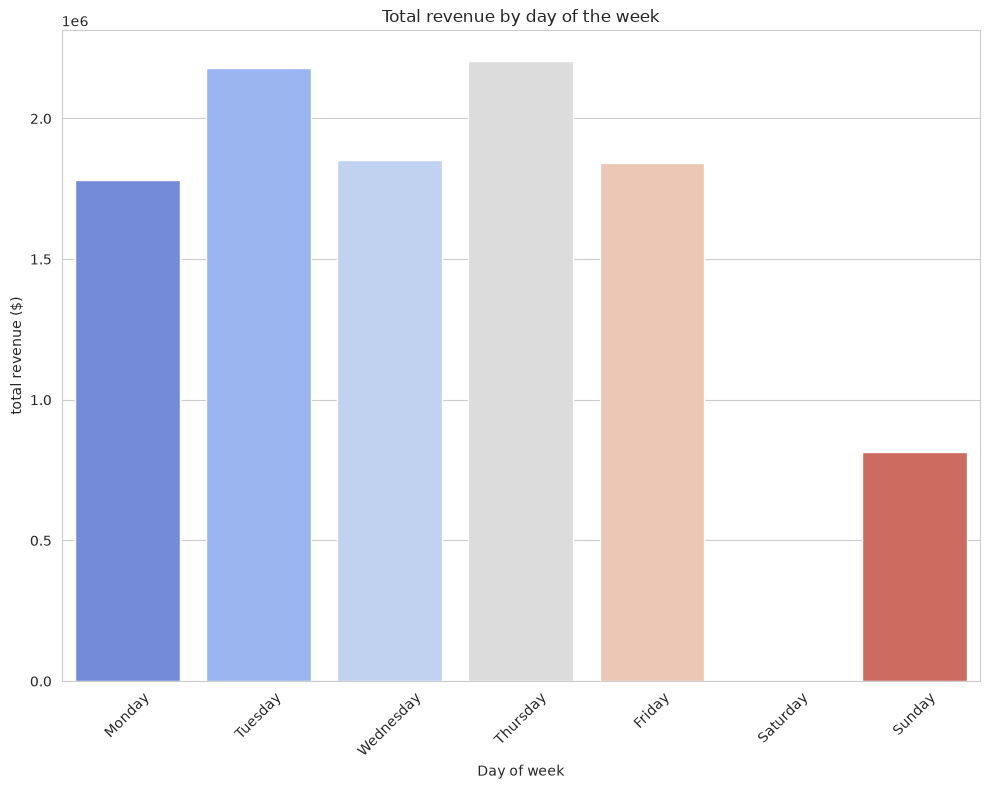

In [46]:
day_order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day=(df_clean.groupby("DayOfWeek")["TotalPrice"]
              .sum()
              .reindex(day_order))
plt.figure()
sns.barplot(
    x=sales_by_day.index,
    y=sales_by_day.values,
    hue=sales_by_day.index,
    palette="coolwarm"
)
plt.title("Total revenue by day of the week")
plt.ylabel("total revenue ($)")
plt.xlabel("Day of week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("day_by_order.png", dpi=150)
plt.show()

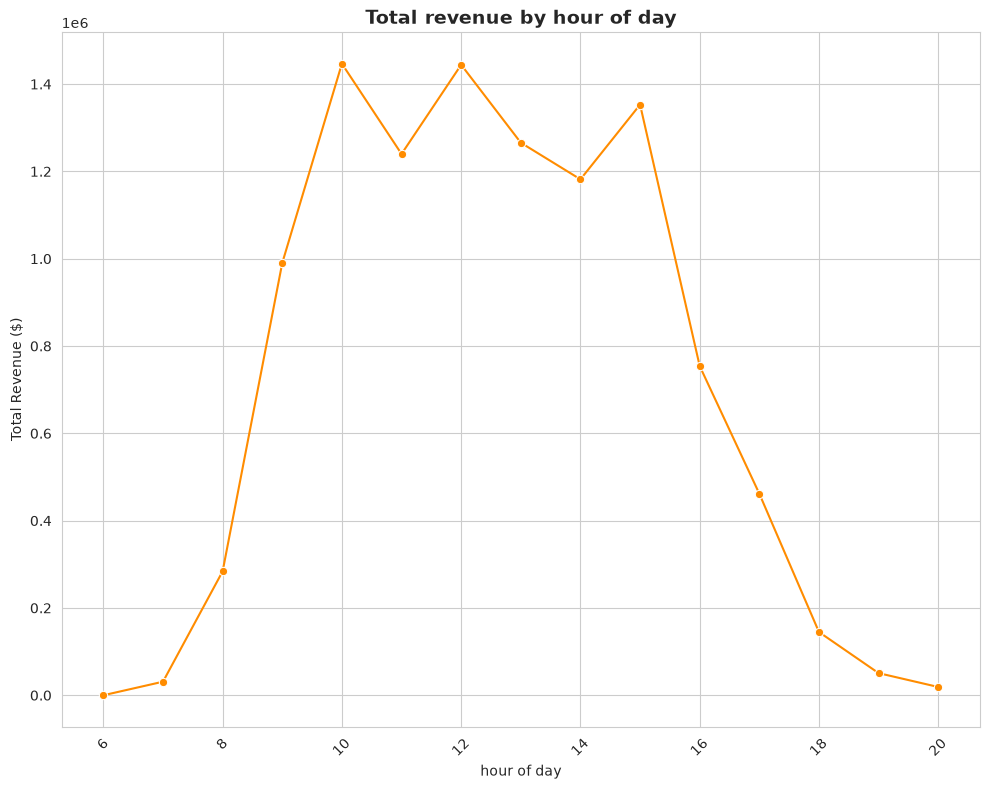

In [47]:
sales_by_hour=df_clean.groupby("Hour")["TotalPrice"].sum()

plt.figure()
sns.lineplot(x=sales_by_hour.index, y=sales_by_hour.values, marker="o", color="darkorange")
plt.title("Total revenue by hour of day", fontsize=14, fontweight="bold")
plt.xlabel("hour of day")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

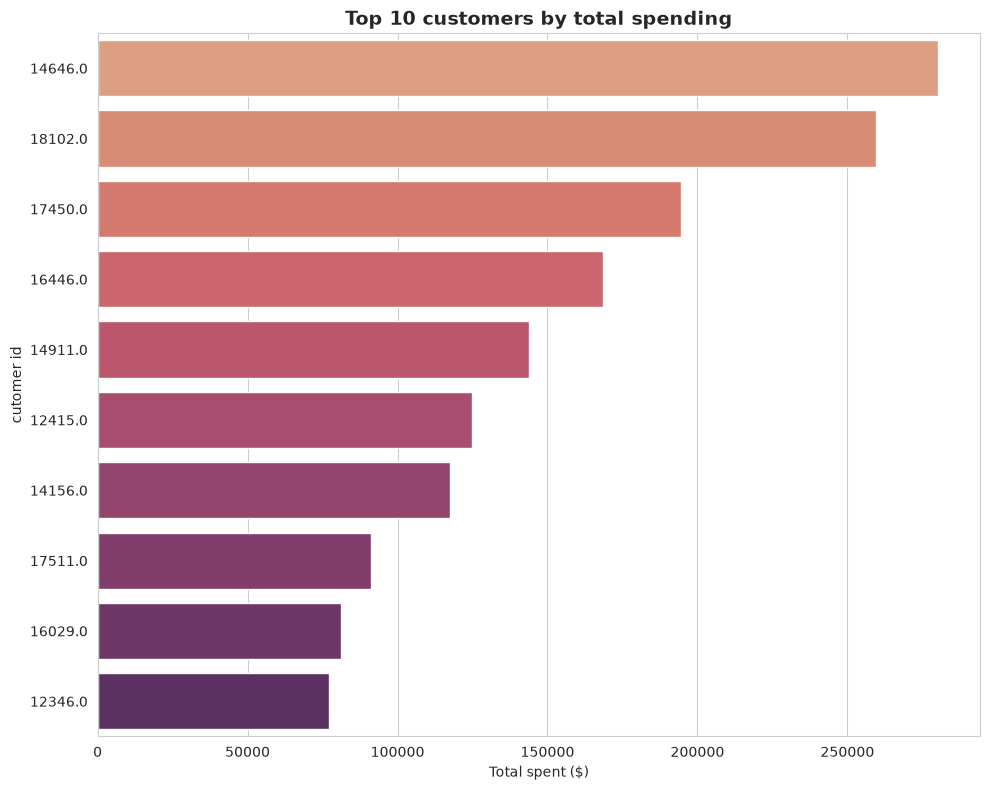

In [48]:
top_cust=cust_summary.head(10)
plt.figure()
sns.barplot(
    x=top_cust["TotalSpent"].values,
    y=top_cust.index.astype(str),
    hue=top_cust.index.astype(str),
    palette="flare"
)
plt.title("Top 10 customers by total spending", fontsize=14, fontweight="bold")
plt.ylabel("cutomer id")
plt.xlabel("Total spent ($)")
plt.tight_layout()
plt.show()

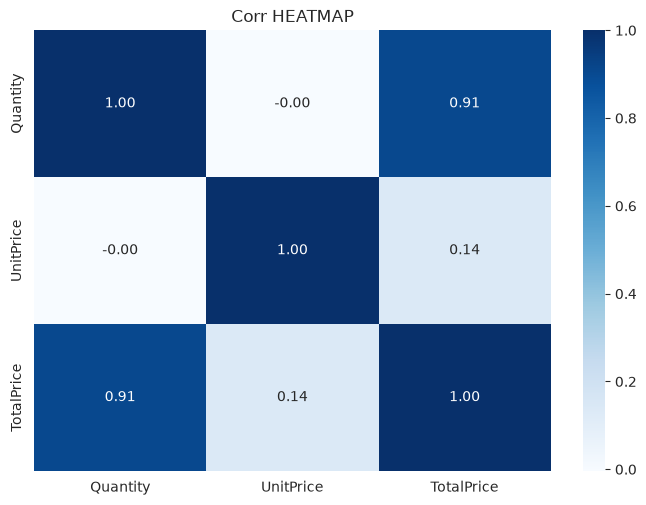

In [49]:
plt.figure(figsize=(7,5))
corr=df_clean[["Quantity", "UnitPrice", "TotalPrice"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.tight_layout()
plt.title("Corr HEATMAP")
plt.show()
        

## Step 13- Machine Learning- Linear regression

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [52]:
ml_data=cust_summary[["NumOrders", "AvgOrderValue", "TotalSpent"]].dropna()
X=ml_data[["NumOrders", "AvgOrderValue"]]
y=ml_data[["TotalSpent"]]
print("feature set shape", X.shape)
print("target set shape", y.shape)

feature set shape (4338, 2)
target set shape (4338, 1)


In [53]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=37
)
print(X_train.shape[0])
print(y_train.shape[0])

3470
3470


In [54]:
model=LinearRegression()
model.fit(X_train,y_train)

print("Model trained")
print("intercept: ", model.intercept_)
print("Coefficients (NumOrders, AvgOrderValue): ", model.coef_)

Model trained
intercept:  [-959.30083787]
Coefficients (NumOrders, AvgOrderValue):  [[675.87941716   1.14800613]]


In [55]:
# Predict Total Spending on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R-squared (R2 Score):", round(r2, 4))

Model Evaluation Metrics
Mean Absolute Error (MAE): 1823.74
Mean Squared Error (MSE): 109249760.83
Root Mean Squared Error (RMSE): 10452.26
R-squared (R2 Score): 0.3075


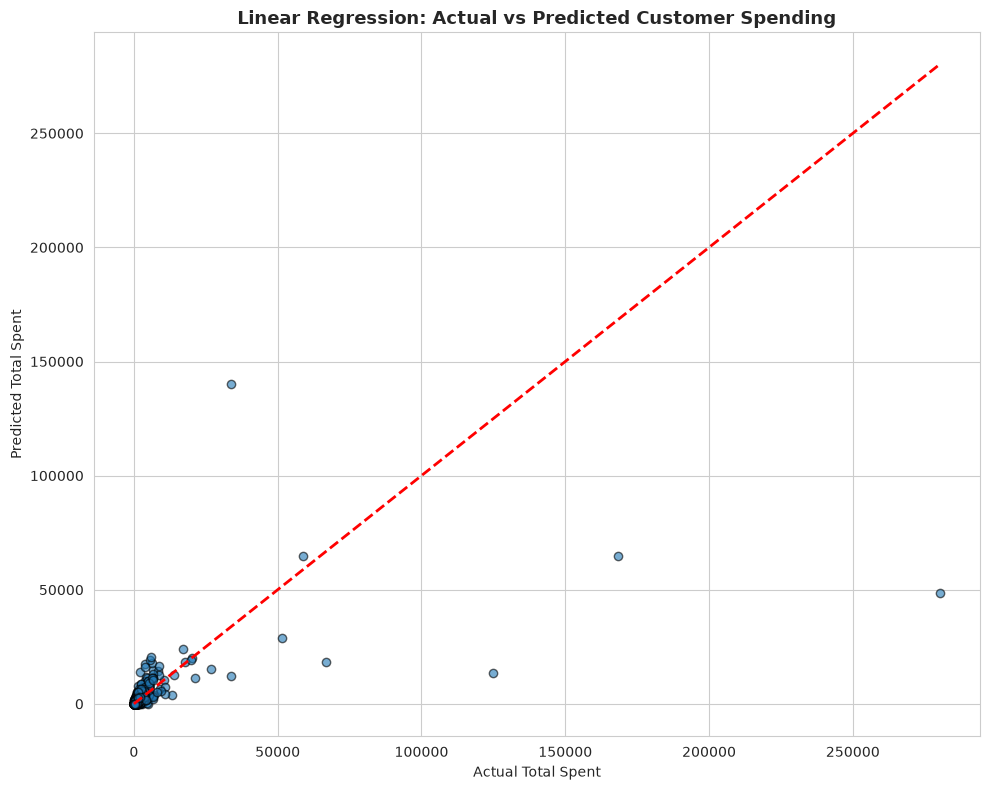

In [56]:
# Visualize Actual vs Predicted Total Spending
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2)
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Linear Regression: Actual vs Predicted Customer Spending", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("linear_regression_actual_vs_predicted.png", dpi=150)
plt.show()

In [57]:
print(model.predict([[11000,3000]]))
print(model.predict([[2000,5000]]))
print(model.predict([[5000,2000]]))
print(model.predict([[13000,7000]]))
print(model.predict([[18000,8000]]))
print(model.predict(X_test))

[[7437158.30634421]]
[[1356539.56413343]]
[[3380733.79723606]]
[[8793509.16518653]]
[[12174054.25713148]]
[[ 5.13007339e+03]
 [-2.57926118e+02]
 [ 1.77048634e+03]
 [ 1.26847315e+03]
 [ 1.73338127e+04]
 [ 1.77872717e+03]
 [ 4.46883977e+03]
 [ 1.76963166e+03]
 [ 6.49418286e+03]
 [ 7.86961983e+03]
 [-2.76612746e+02]
 [ 4.12258232e+02]
 [-2.65185573e+02]
 [-1.87948926e+02]
 [-2.66086528e+02]
 [ 2.47894075e+03]
 [-2.60010706e+02]
 [ 1.10706863e+03]
 [-1.09307158e+02]
 [ 8.63283933e+01]
 [ 1.75769301e+03]
 [ 1.75582759e+03]
 [-2.79698564e+02]
 [ 3.98044065e+02]
 [ 1.76555508e+03]
 [-2.55751193e+02]
 [-2.79116398e+02]
 [-2.64720401e+02]
 [ 3.12639660e+03]
 [ 1.46674551e+04]
 [ 1.75304615e+03]
 [-2.58657288e+02]
 [ 2.45230916e+03]
 [-2.79207008e+02]
 [ 4.07439476e+02]
 [-2.64077517e+02]
 [ 3.79773940e+03]
 [ 3.79043340e+03]
 [ 1.09261463e+03]
 [ 3.11742582e+03]
 [ 7.17304583e+03]
 [ 5.15157444e+03]
 [ 1.09364412e+03]
 [ 2.44450403e+03]
 [-2.63495314e+02]
 [-2.61449908e+02]
 [ 4.62836512e+02]
 

/home/avanisinghchauhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/avanisinghchauhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/avanisinghchauhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/avanisinghchauhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/avanisinghchauhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but Line